# SARIMAX

## 1. Imports

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from hydrosense.database.bigquery import load_plean
from hydrosense.params import *

## 2. Chargement des données
Lecture du fichier CSV contenant les relevés piézométriques du piézomètre Bourdet.

In [2]:
!cd /home/charourou/projects/Projet_Hydrosense
!pwd


/home/charourou/projects/Projet_Hydrosense/notebooks/pres


In [12]:
DATA_CODE_PIEZO = "BSS001QHYH"
DATA_CODE_PIEZO = TARGETS_BSS[10]
df_plean = load_plean(DATA_CODE_PIEZO)


✅ BSS001VAJT : 11994 lignes de features ML chargées.


### Mise en forme de l'index
Conversion de la colonne `date_mesure` en index temporel de type `DatetimeIndex`.

In [ ]:
df = df_plean.copy()
df.set_index(DATE_COL, inplace = True, drop = True)
df.index = pd.to_datetime(df.index)

y = df[TARGET_COL]

### Visualisation brute de la série
Premier aperçu de l'évolution du niveau de la nappe phréatique sur toute la période disponible.

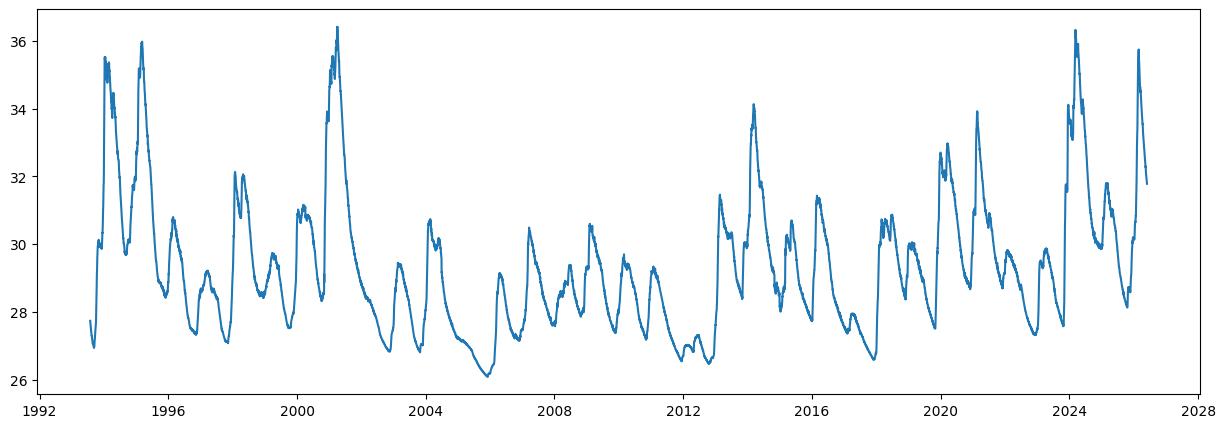

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,5));
plt.plot(y);

### Stats basiques

La distribution est loin d'être normale. Il y a une grosse skewness pour certains piezos.

Skewness 1.0771826100835697


count    11994.000000
mean        29.362084
std          2.010931
min         26.090000
25%         27.890000
50%         28.990000
75%         30.300000
max         36.410000
Name: niveau_nappe_eau, dtype: float64

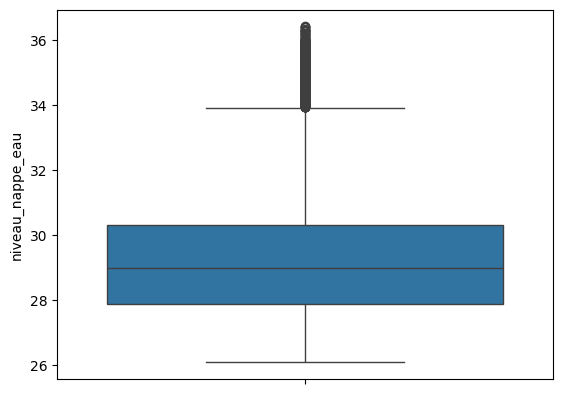

In [ ]:
sns.boxplot(y)
print('Skewness',y.skew())
y.describe()

Skewness de la dérivée 2.930406796834868


Text(0.5, 1.0, 'Derivée niveau nappe')

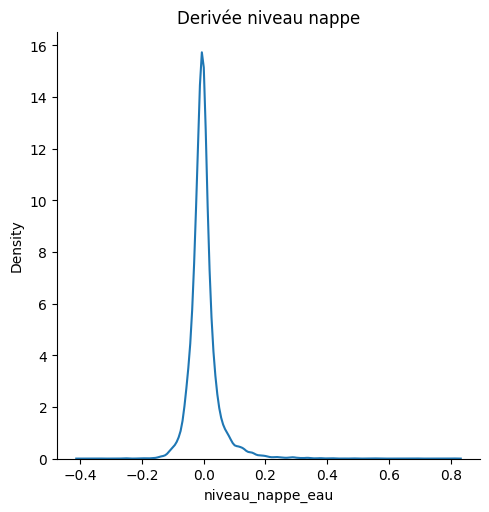

In [24]:
y_diff = y.diff().dropna()
print('Skewness de la dérivée', y_diff.skew())
sns.displot(y_diff, kind='kde')
plt.title('Derivée niveau nappe')

## 3. Décomposition saisonnière
Décomposition additive de la série : **y = Tendance + Saisonnalité + Résidus**.

On utilise `period=365` pour capturer la saisonnalité annuelle sur des données journalières.

Deviations standards : 
Total :  2.01
Composante saisonnière :  0.92 
 Residus :  0.71


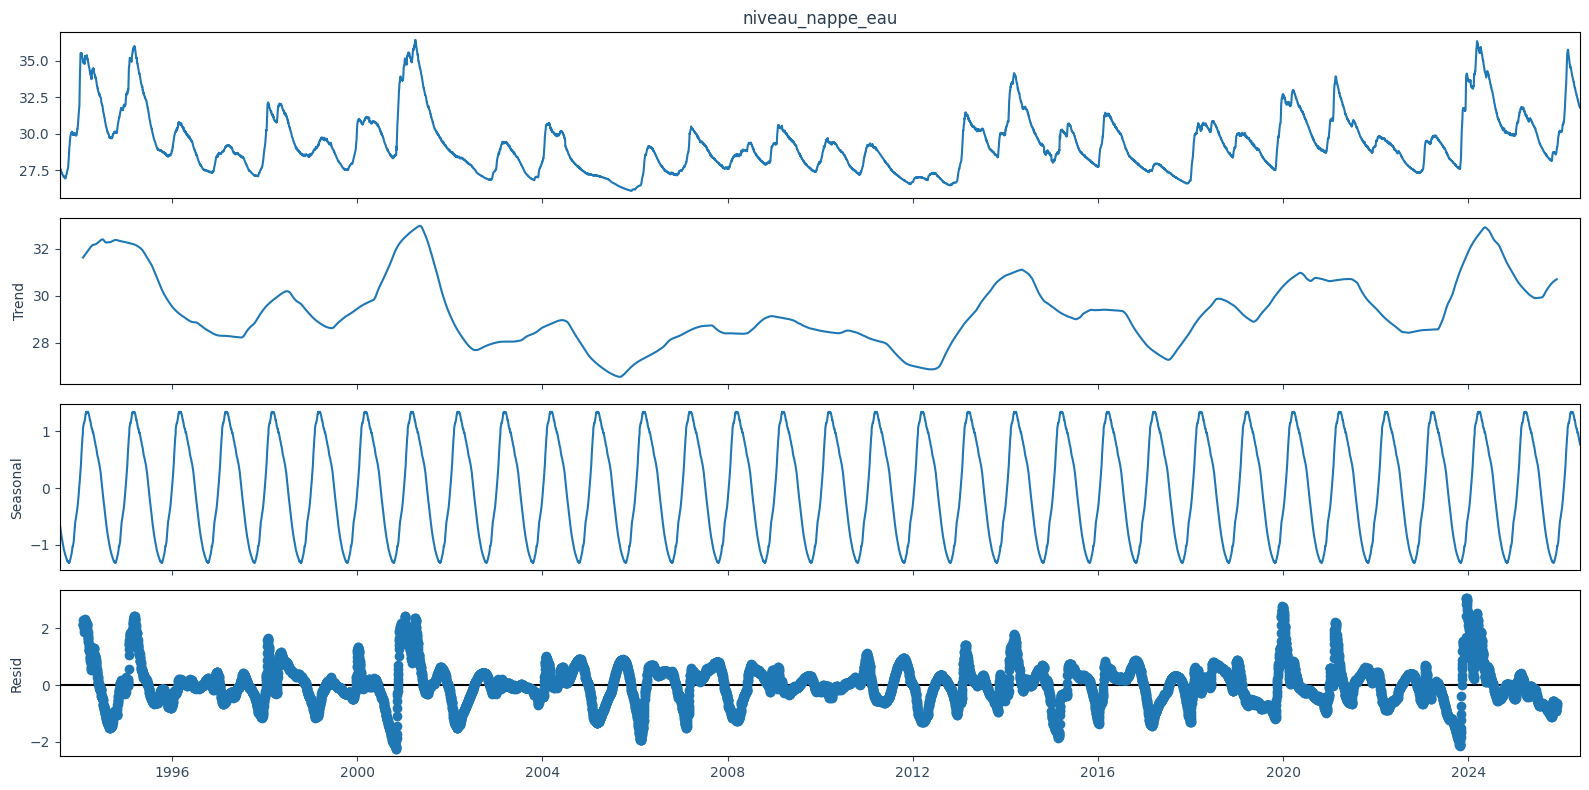

In [27]:
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose

# Additive Decomposition (y = Trend + Seasonal + Residuals)
result_add = seasonal_decompose(y,
                                model='additive', period=366)

plt.rc("figure", figsize=(16,8))

multipl_plot = result_add.plot()

print('Deviations standards : ')
print('Total : ', round( result_add._observed.std() , 2) )
print('Composante saisonnière : ', round( result_add._seasonal.std() , 2) , '\n Residus : ',
            round(result_add._resid.std() , 2) )


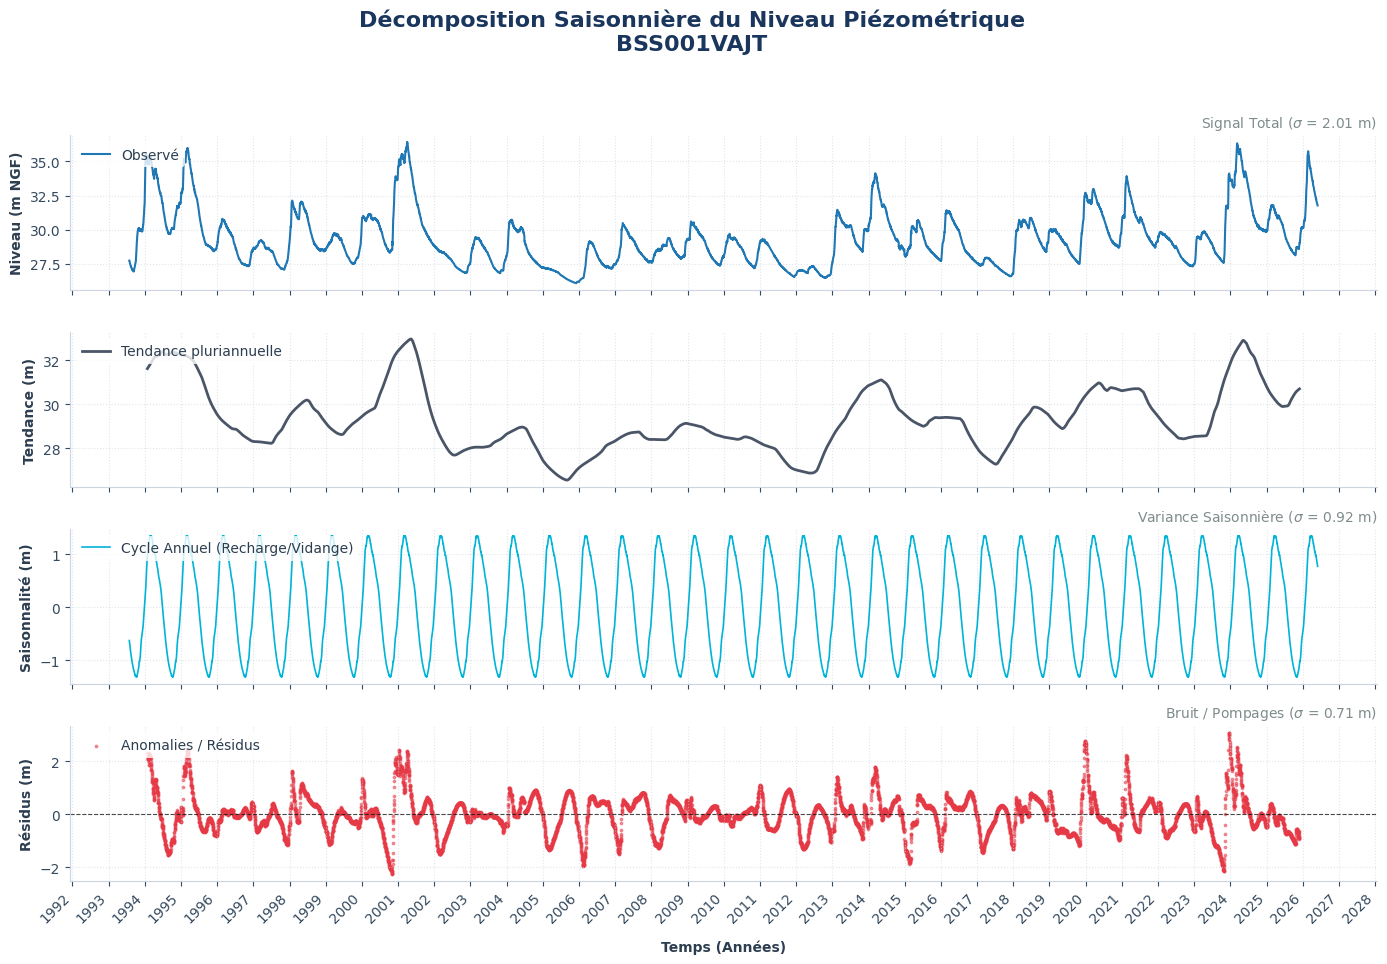

In [29]:
# Calcul des écarts-types pour l'analyse hydrogéologique
std_tot = result_add._observed.std()
std_seas = result_add._seasonal.std()
std_resid = result_add._resid.std()

# --- 2. Configuration de la Charte Graphique ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#2c3e50'
plt.rcParams['axes.labelcolor'] = '#2c3e50'
plt.rcParams['xtick.color'] = '#34495e'
plt.rcParams['ytick.color'] = '#34495e'

# Création des 4 subplots partageant le même axe X (temporel)
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f"Décomposition Saisonnière du Niveau Piézométrique\n{DATA_CODE_PIEZO}",
             fontsize=16, fontweight='bold', color='#1a365d', y=0.96)

# Couleurs thématiques
colors = ['#1f77b4', '#4a5568', '#00b4d8', '#e63946']

# --- Subplot 1 : Signal Observé ---
axes[0].plot(result_add.observed, color=colors[0], linewidth=1.5, label='Observé')
axes[0].set_ylabel('Niveau (m NGF)', fontweight='bold')
axes[0].legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
axes[0].set_title(f"Signal Total ($\sigma$ = {std_tot:.2f} m)", loc='right', fontsize=10, color='#7f8c8d')

# --- Subplot 2 : Tendance (Trend) ---
axes[1].plot(result_add.trend, color=colors[1], linewidth=2, label='Tendance pluriannuelle')
axes[1].set_ylabel('Tendance (m)', fontweight='bold')
axes[1].legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')

# --- Subplot 3 : Saisonnalité (Seasonal) ---
axes[2].plot(result_add.seasonal, color=colors[2], linewidth=1.2, label='Cycle Annuel (Recharge/Vidange)')
axes[2].set_ylabel('Saisonnalité (m)', fontweight='bold')
axes[2].legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
axes[2].set_title(f"Variance Saisonnière ($\sigma$ = {std_seas:.2f} m)", loc='right', fontsize=10, color='#7f8c8d')

# --- Subplot 4 : Résidus (Residuals) ---
axes[3].scatter(result_add.resid.index, result_add.resid, color=colors[3], s=3, alpha=0.5, label='Anomalies / Résidus')
axes[3].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
axes[3].set_ylabel('Résidus (m)', fontweight='bold')
axes[3].legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
axes[3].set_title(f"Bruit / Pompages ($\sigma$ = {std_resid:.2f} m)", loc='right', fontsize=10, color='#7f8c8d')

# --- 3. Optimisation des Axes et de la Grille ---
for ax in axes:
    ax.grid(True, linestyle=':', alpha=0.6, color='#cbd5e1')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cbd5e1')
    ax.spines['bottom'].set_color('#cbd5e1')

# Formatage de l'axe temporel (X) du bas
axes[3].xaxis.set_major_locator(mdates.YearLocator())
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[3].set_xlabel('Temps (Années)', fontweight='bold', fontsize=10, labelpad=10)
plt.setp(axes[3].get_xticklabels(), rotation=45, ha='right')

# Ajustement des marges
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### Visualisation des résidus seuls
Isolation de la composante résiduelle après décomposition.

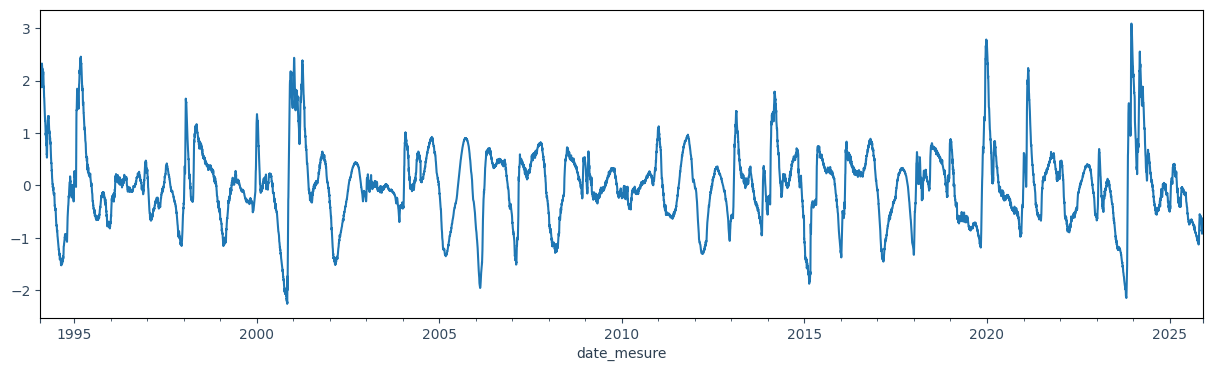

In [30]:
plt.figure(figsize=(15,4));
result_add.resid.dropna().plot();

### Box Plot des residus


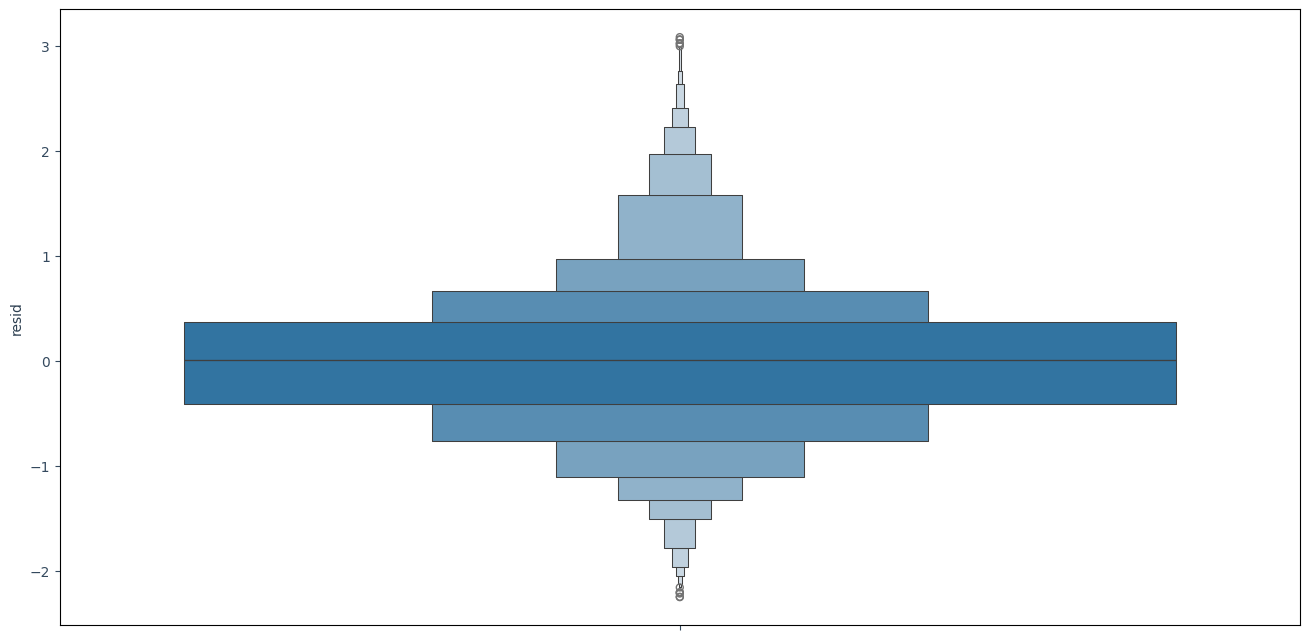

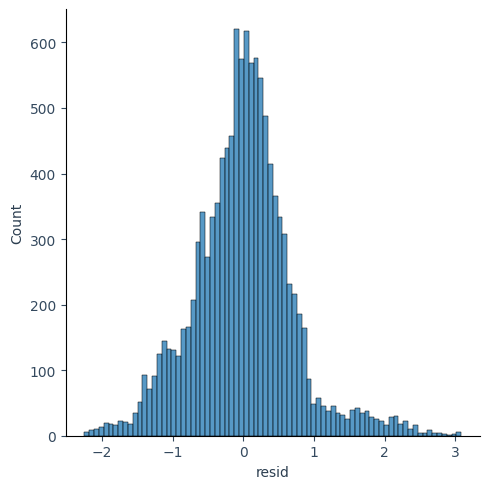

In [31]:
sns.boxenplot(result_add._resid)
sns.displot(result_add._resid)

### Test de stationnarité ADF sur les résidus
Le test de Dickey-Fuller augmenté (ADF) vérifie si les résidus sont stationnaires.

> **Règle de décision** : si la p-value < 0.05, on rejette H₀ (présence de racine unitaire) → les résidus sont stationnaires.

In [32]:
from statsmodels.tsa.stattools import adfuller

print('additive resid: ', adfuller(result_add.resid.dropna())[1])

additive resid:  1.2946257508302773e-19


## 4. Analyse ACF / PACF
Import des outils de visualisation des fonctions d'autocorrélation.

In [33]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

### Calcul de la série différenciée
On différencie la série brute (ordre 1) pour la rendre stationnaire avant l'analyse ACF/PACF.

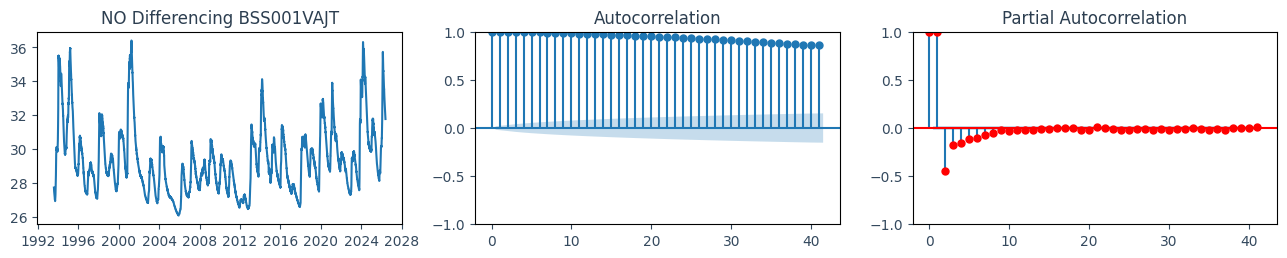

In [36]:
# ACF / PACF analysis of y_
fig, axes = plt.subplots(1,3, figsize=(16,2.5))

# Differencing
axes[0].plot(y); axes[0].set_title(f'NO Differencing {DATA_CODE_PIEZO}')
# ACF
plot_acf(y, ax=axes[1]);
# PACF
plot_pacf(y, ax=axes[2], c='r');

### ACF et PACF — vue condensée
Analyse des autocorrélations pour identifier les ordres **p** (AR) et **q** (MA) :
- **ACF** : décroissance progressive → composante MA
- **PACF** : coupure nette après le lag k → composante AR(k)

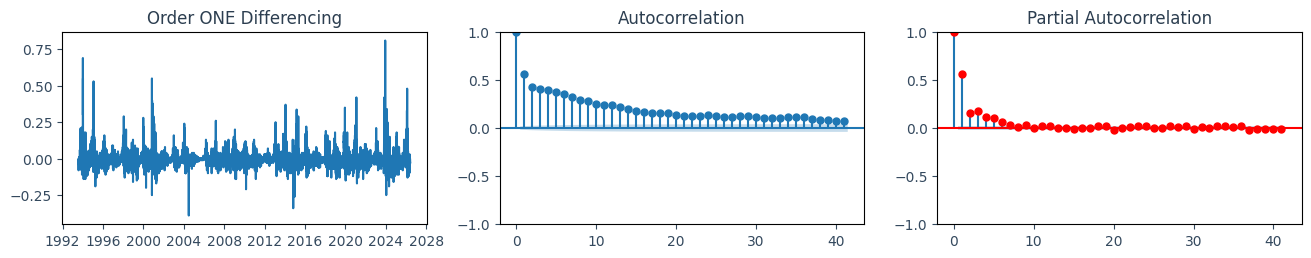

In [ ]:
# ACF / PACF analysis of y_diff linearized
fig, axes = plt.subplots(1,3, figsize=(16,2.5))

# Differencing
axes[0].plot(y_diff); axes[0].set_title(f'Order ONE Differencing {DATA_CODE_PIEZO}')
# ACF
plot_acf(y_diff, ax=axes[1]);
# PACF
plot_pacf(y_diff, ax=axes[2], c='r');

### ACF et PACF — vue détaillée

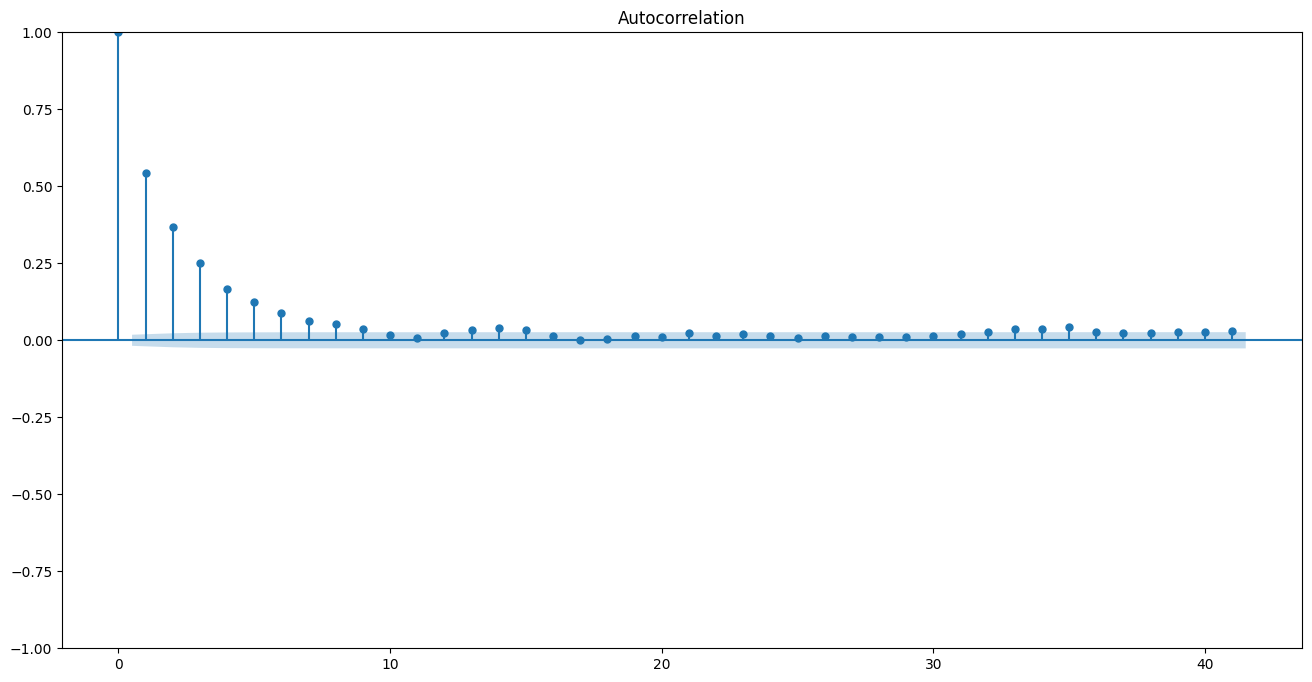

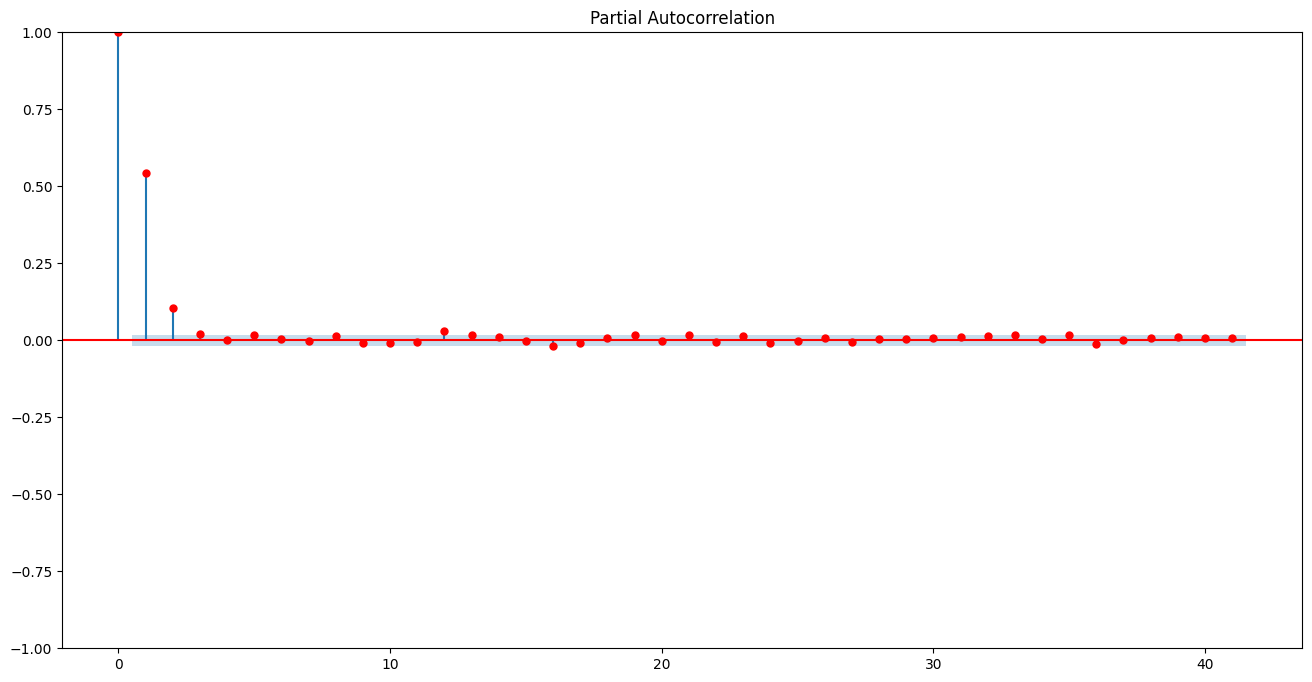

In [116]:
plot_acf(y_diff);

# PACF
plot_pacf(y_diff, c='r');

## 5. Modèles ARIMA exploratoires
Test manuel de deux configurations ARIMA sur la série journalière différenciée (`d=1`).

In [117]:
from statsmodels.tsa.arima.model import ARIMA


# On donne la série brute 'y', et on dit à l'ARIMA de la différencier 1 fois (d=1)
model = ARIMA(y, order=(0, 1, 2))
arima = model.fit()
arima.summary()

/Users/romainhuchet/.pyenv/versions/3.10.6/envs/Projet_Hydrosense/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/romainhuchet/.pyenv/versions/3.10.6/envs/Projet_Hydrosense/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/romainhuchet/.pyenv/versions/3.10.6/envs/Projet_Hydrosense/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:       niveau_nappe_eau   No. Observations:                11807
Model:                 ARIMA(0, 1, 2)   Log Likelihood               14973.675
Date:                Wed, 03 Jun 2026   AIC                         -29941.350
Time:                        11:43:38   BIC                         -29919.221
Sample:                    02-01-1994   HQIC                        -29933.921
                         - 05-30-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.4666      0.003    165.413      0.000       0.461       0.472
ma.L2          0.2464      0.005     45.025      0.000       0.236       0.257
sigma2         0.0046   1.06e-05    438.548      0.000       0.005       0.005
===================================================================================
Ljung-Box (L1) (Q):                  22.22   Jarque-Bera (JB):           2147924.09
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.75   Skew:                             5.49
Prob(H) (two-sided):                  0.00   Kurtosis:                        68.16
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [118]:
model = ARIMA(y, order=(1, 1, 1))
arima = model.fit()
arima.summary()

/Users/romainhuchet/.pyenv/versions/3.10.6/envs/Projet_Hydrosense/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/romainhuchet/.pyenv/versions/3.10.6/envs/Projet_Hydrosense/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/romainhuchet/.pyenv/versions/3.10.6/envs/Projet_Hydrosense/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:       niveau_nappe_eau   No. Observations:                11807
Model:                 ARIMA(1, 1, 1)   Log Likelihood               15241.047
Date:                Wed, 03 Jun 2026   AIC                         -30476.094
Time:                        11:43:39   BIC                         -30453.965
Sample:                    02-01-1994   HQIC                        -30468.665
                         - 05-30-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6781      0.007     92.090      0.000       0.664       0.693
ma.L1         -0.1929      0.008    -22.795      0.000      -0.210      -0.176
sigma2         0.0044   9.73e-06    454.986      0.000       0.004       0.004
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):           2438102.41
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               0.77   Skew:                             5.51
Prob(H) (two-sided):                  0.00   Kurtosis:                        72.53
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## 6. Sélection automatique — auto_arima (journalier)
Utilisation de `pmdarima.auto_arima` sur la série journalière brute.

> `seasonal=False` est obligatoire ici : avec `m=365`, le temps de calcul explose. La saisonnalité sera prise en compte dans les étapes suivantes via le rééchantillonnage.

In [119]:
!pip install pmdarima

In [120]:
import pmdarima as pm

model = pm.auto_arima(
    y,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=None,            # Le modèle va déterminer 'd' tout seul comme un grand
    test='adf',        # En utilisant le test Augmented Dickey-Fuller (ADF)
    seasonal=False,    # OBLIGATOIRE sur du journalier long pour éviter que la machine ne plante
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=92749.352, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.29 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.56 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-29103.302, Time=0.78 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-30466.683, Time=0.45 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.51 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-30463.263, Time=1.58 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-30464.767, Time=0.80 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-29931.566, Time=1.12 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.47 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=3.72 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-30526.291, Time=0.85 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-29124.293, Time=0.84 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.97 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=-30518

### Prédiction exploratoire à 30 jours
Visualisation rapide des prédictions de l'auto_arima sur les données journalières.

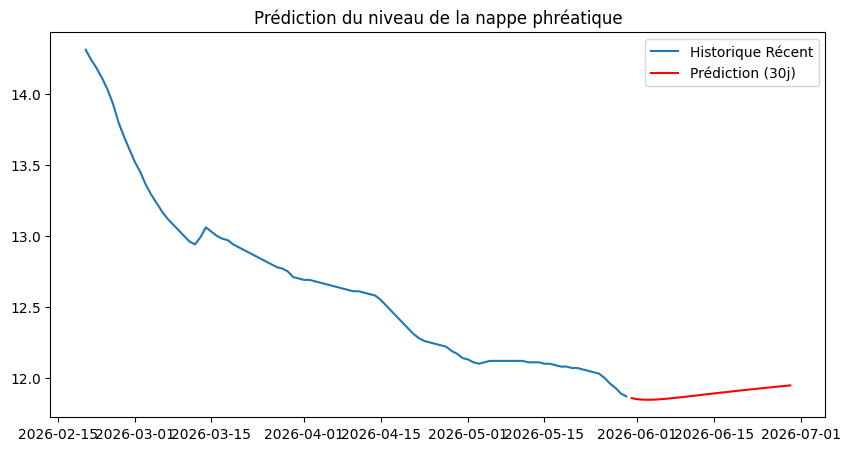

In [121]:
# Prédire les 30 prochains jours
forecast = model.predict(n_periods=30)

# Pour tracer le graphique de tes prédictions
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y.tail(100), label="Historique Récent") # Les 100 derniers jours réels
plt.plot(forecast, label="Prédiction (30j)", color='red')
plt.title("Prédiction du niveau de la nappe phréatique")
plt.legend()
plt.show()

## 7. Modèle SARIMAX — Données mensuelles
On rééchantillonne la série en **mensuel** (`resample('M')`) pour permettre l'utilisation d'une saisonnalité annuelle `m=12`, beaucoup plus stable computationnellement qu'un `m=365` journalier.

**Modèle retenu :** `SARIMAX(1,0,1)(1,0,0)[12]`

/var/folders/t7/yyn72hx91dqgyy1t_nnvkxmh0000gn/T/ipykernel_98713/2500980853.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  y_mensuel = df["niveau_nappe_eau"].resample('M').mean()


Nombre de mois d'entraînement (1994 - 2025) : 376
Nombre de mois de test (Dernière année) : 12


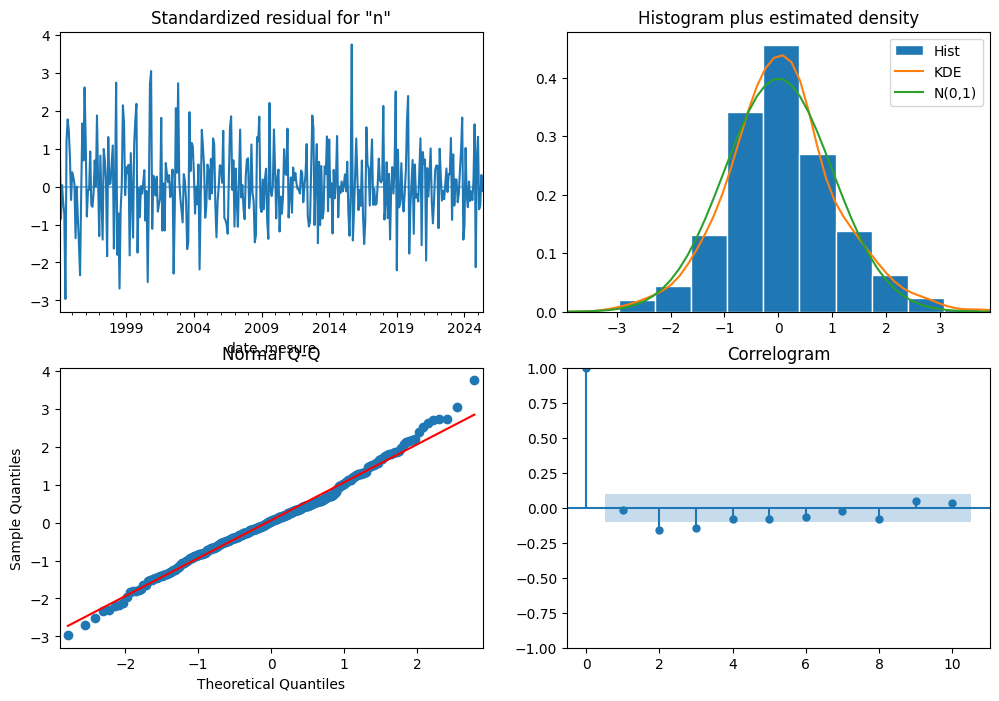

                                      SARIMAX Results                                      
Dep. Variable:                    niveau_nappe_eau   No. Observations:                  376
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 12)   Log Likelihood                -379.354
Date:                             Wed, 03 Jun 2026   AIC                            766.708
Time:                                     11:59:49   BIC                            782.426
Sample:                                 02-28-1994   HQIC                           772.947
                                      - 05-31-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9921      0.007    134.358      0.000       0.978       1.007
ma.L1          0.0941      

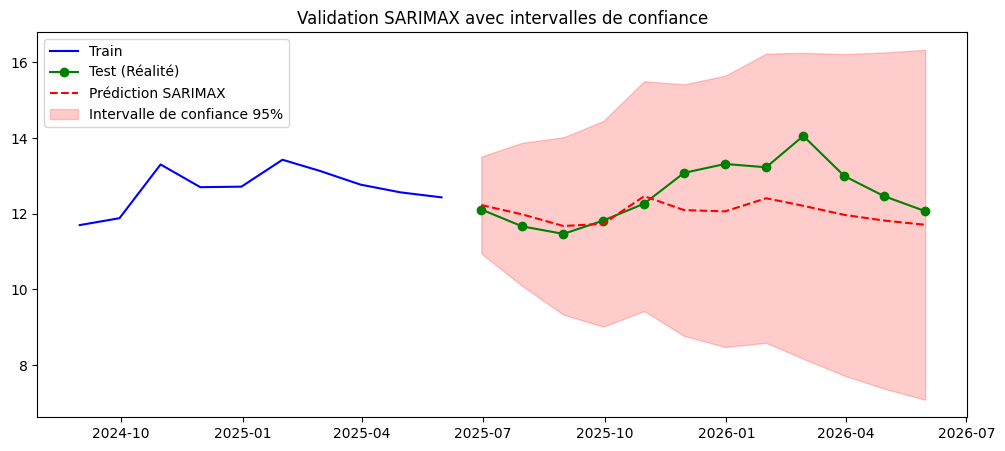

In [128]:
# ==========================================
# 1. PASSER EN DONNÉES MENSUELLES (Crucial !)
# ==========================================
# On prend la moyenne mensuelle pour lisser les données journalières
y_mensuel = df["niveau_nappe_eau"].resample('M').mean()

# ==========================================
# 2. TRAIN / TEST SPLIT (Dernière année en Test)
# ==========================================
# Ton dataset s'arrête le 2026-05-31. L'année de test va donc de Juin 2025 à Mai 2026 (12 mois)
train = y_mensuel.loc[:'2025-05-31']
test = y_mensuel.loc['2025-06-01':'2026-05-31']

print(f"Nombre de mois d'entraînement (1994 - 2025) : {len(train)}")
print(f"Nombre de mois de test (Dernière année) : {len(test)}")

# ==========================================
# 3. ENTRAÎNEMENT DU MODÈLE FINAL
# ==========================================
from statsmodels.tsa.statespace.sarimax import SARIMAX

# On configure le modèle sur le Train uniquement
model = SARIMAX(train, order=(1, 0, 1), seasonal_order=(1, 0, 0, 12))
arima_fitted = model.fit()

arima_fitted.plot_diagnostics(figsize=(12, 8))
plt.show()

# Affichage du résumé optimisé
print(arima_fitted.summary())


forecast_obj = arima_fitted.get_forecast(steps=len(test))
forecast_mean = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

plt.figure(figsize=(12, 5))
plt.plot(train.tail(10), label='Train', color='blue')
plt.plot(test, label='Test (Réalité)', color='green', marker='o')
plt.plot(forecast_mean, label='Prédiction SARIMAX', color='red', linestyle='--')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='red', alpha=0.2, label='Intervalle de confiance 95%')
plt.title("Validation SARIMAX avec intervalles de confiance")
plt.legend()
plt.show()

### Métriques d'évaluation — Mensuel
Calcul du MAE, RMSE et MAPE sur la période de test (juin 2025 → mai 2026).

In [125]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"MAE : {mae:.4f} m | RMSE : {rmse:.4f} m")

MAE : 0.6552 m | RMSE : 0.8381 m


## 8. Modèle SARIMAX — Données hebdomadaires
On rééchantillonne en **hebdomadaire** (`resample('W')`) pour un meilleur compromis entre granularité et stabilité.

L'`auto_arima` est relancé avec `seasonal=True` et `m=52` (52 semaines/an) pour identifier les meilleurs paramètres saisonniers.

**Modèle retenu après sélection AIC :** `SARIMAX(2,0,1)(2,0,0)[52]` — AIC = 589.838

In [129]:
# Rééchantillonnage en hebdomadaire (moyenne par semaine)
y_weekly = df['niveau_nappe_eau'].resample('W').mean()

import pmdarima as pm

model = pm.auto_arima(
    y_weekly,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=None,
    test='adf',
    seasonal=True,      # On peut activer la saisonnalité en hebdomadaire
    m=52,               # 52 semaines dans une année
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=None,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=5330.290, Time=0.10 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=938.051, Time=16.11 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=2901.363, Time=5.94 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=13253.725, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[52] intercept   : AIC=982.774, Time=0.07 sec
 ARIMA(1,0,0)(2,0,0)[52] intercept   : AIC=879.524, Time=39.47 sec
 ARIMA(1,0,0)(2,0,1)[52] intercept   : AIC=inf, Time=56.17 sec
 ARIMA(1,0,0)(1,0,1)[52] intercept   : AIC=inf, Time=15.51 sec
 ARIMA(0,0,0)(2,0,0)[52] intercept   : AIC=inf, Time=26.80 sec
 ARIMA(2,0,0)(2,0,0)[52] intercept   : AIC=608.755, Time=32.98 sec
 ARIMA(2,0,0)(1,0,0)[52] intercept   : AIC=inf, Time=15.94 sec
 ARIMA(2,0,0)(2,0,1)[52] intercept   : AIC=inf, Time=62.18 sec
 ARIMA(2,0,0)(1,0,1)[52] intercept   : AIC=inf, Time=16.55 sec
 ARIMA(3,0,0)(2,0,0)[52] intercept   : AIC=596.199, Time=48.79 sec
 ARIMA(3,0,0)(1,0,0)[52] intercept   : AIC=

### Train / Test split — Hebdomadaire
Découpage de la série hebdomadaire : entraînement jusqu'en mai 2025, test sur les 12 derniers mois.

In [138]:
y_weekly = df['niveau_nappe_eau'].resample('W').mean()
train = y_weekly.loc[:'2025-05-31']
test  = y_weekly.loc['2025-06-01':'2026-05-31']

### Entraînement du modèle SARIMAX hebdomadaire
Ajustement du modèle `SARIMAX(2,0,1)(2,0,0)[52]` sur les données d'entraînement.

In [142]:
model = SARIMAX(train,
                order=(2, 0, 1),
                seasonal_order=(2, 0, 0, 52))
arima_fitted = model.fit()

/Users/romainhuchet/.pyenv/versions/3.10.6/envs/Projet_Hydrosense/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


### Diagnostic, prédiction et évaluation — Hebdomadaire
Validation complète du modèle :
- **Diagnostic des résidus** : vérification que les résidus sont du bruit blanc (QQ-plot, Ljung-Box)
- **Prédiction avec intervalles de confiance à 95%**
- **Métriques** : MAE, RMSE, MAPE

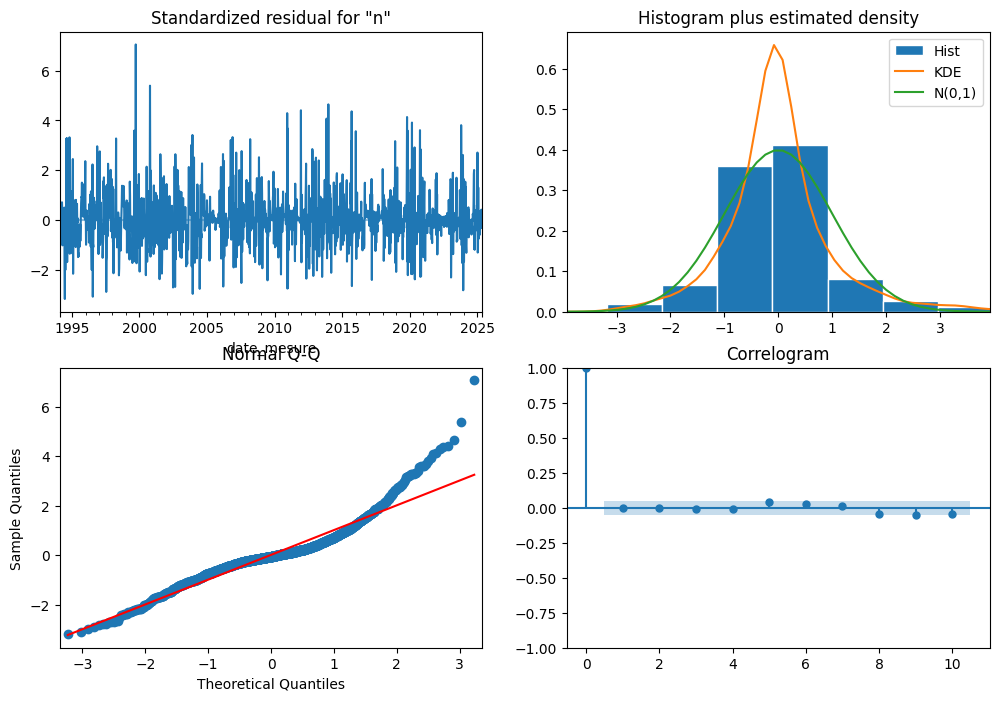

                                      SARIMAX Results                                      
Dep. Variable:                    niveau_nappe_eau   No. Observations:                 1634
Model:             SARIMAX(2, 0, 1)x(2, 0, [], 52)   Log Likelihood                -334.832
Date:                             Wed, 03 Jun 2026   AIC                            681.664
Time:                                     13:05:57   BIC                            714.057
Sample:                                 02-06-1994   HQIC                           693.680
                                      - 05-25-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0504      0.001    941.565      0.000       1.048       1.053
ar.L2         -0.0510      

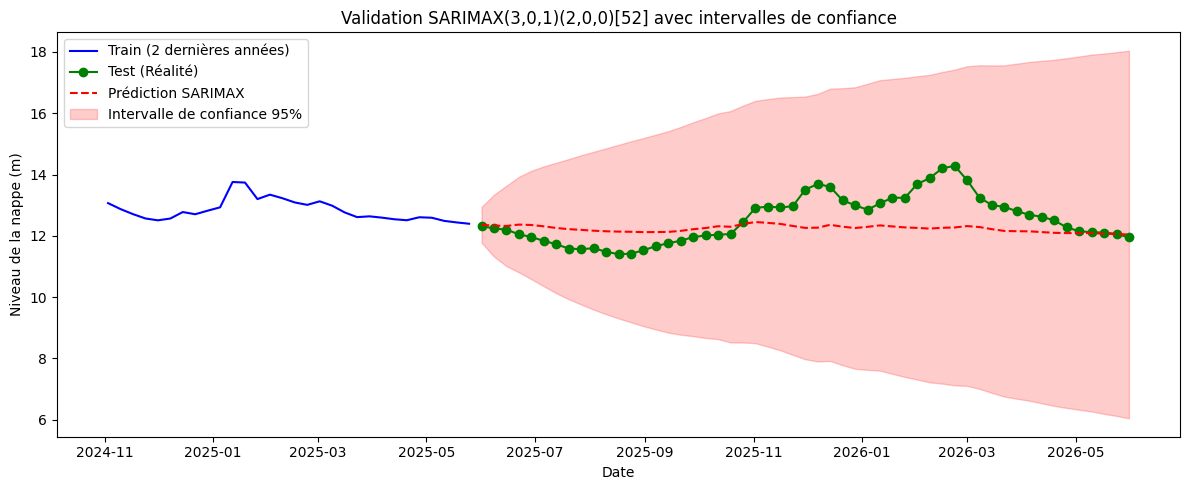

MAE  : 0.6258 m
RMSE : 0.7874 m
MAPE : 4.85 %


In [143]:
arima_fitted.plot_diagnostics(figsize=(12, 8))
plt.show()
print(arima_fitted.summary())

# Prédiction avec intervalles de confiance
forecast_obj  = arima_fitted.get_forecast(steps=len(test))
forecast_mean = forecast_obj.predicted_mean
conf_int      = forecast_obj.conf_int()

# Alignement des index
forecast_mean.index = test.index
conf_int.index      = test.index

# Graphique
plt.figure(figsize=(12, 5))
plt.plot(train.tail(30), label='Train (2 dernières années)', color='blue')
plt.plot(test, label='Test (Réalité)', color='green', marker='o')
plt.plot(forecast_mean, label='Prédiction SARIMAX', color='red', linestyle='--')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='red', alpha=0.2, label='Intervalle de confiance 95%')
plt.title("Validation SARIMAX(3,0,1)(2,0,0)[52] avec intervalles de confiance")
plt.xlabel("Date")
plt.ylabel("Niveau de la nappe (m)")
plt.legend()
plt.tight_layout()
plt.show()

# Métriques
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae  = mean_absolute_error(test, forecast_mean)
rmse = np.sqrt(mean_squared_error(test, forecast_mean))
mape = (abs((test.values - forecast_mean.values) / test.values).mean()) * 100

print(f"MAE  : {mae:.4f} m")
print(f"RMSE : {rmse:.4f} m")
print(f"MAPE : {mape:.2f} %")